# Claim Detection Classifier — Training

Fine-tunes **DeBERTa-v3-base** to classify text as:
- `CLAIM` — verifiable factual assertion
- `NOT_CLAIM` — opinion, question, gibberish

Used as a fast pre-filter in Verifyn: if NOT_CLAIM with high confidence, skip expensive LLM agent.

## 0. Setup

In [1]:
import csv
import json
import logging
import os
import random
import re
import time
from pathlib import Path
from datasets import load_dataset

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU")

Device: cuda
GPU: Tesla T4


## 1. Config

In [2]:
# All config in one place — same as classifier/config.yaml
CONFIG = {
    "model_base": "microsoft/deberta-v3-base",
    "num_labels": 2,
    "max_length": 256,
    "epochs": 5,
    "batch_size": 16,
    "eval_batch_size": 32,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "seed": 42,
    "early_stopping_patience": 2,
    "output_dir": "claim_detector_model",
    "mlflow_experiment": "verifyn-claim-detector",
}

print(json.dumps(CONFIG, indent=2))

{
  "model_base": "microsoft/deberta-v3-base",
  "num_labels": 2,
  "max_length": 256,
  "epochs": 5,
  "batch_size": 16,
  "eval_batch_size": 32,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "seed": 42,
  "early_stopping_patience": 2,
  "output_dir": "claim_detector_model",
  "mlflow_experiment": "verifyn-claim-detector"
}


## 2. Load Data

Load ClaimBuster dataset

In [3]:
ds = load_dataset("Nithiwat/claim-detection")
print(f"Splits: {list(ds.keys())}")
for split_name, split_ds in ds.items():
    print(f"  {split_name}: {len(split_ds)} rows")

df = ds["train"].to_pandas()
print(f"\nColumns: {list(df.columns)}")
df.head(10)

Splits: ['train', 'test', 'valid']
  train: 23276 rows
  test: 7274 rows
  valid: 5819 rows

Columns: ['text', 'checkworthiness']


,text,checkworthiness
0,The cost-saving measures we put into place at ...,1
1,You get shot walking to the store.,0
2,If Gov. Rick Scott activates the National Guar...,1
3,"Weve got an average of 5,600 soldiers committi...",1
4,Planned Parenthood is nothing more than a refe...,1
5,"""Obama says Iran is a 'tiny' country, 'doesn't...",1
6,What's involved here is the question of leader...,0
7,Now Senator Kennedy has made some very strong ...,0
8,We have been discouraged and we've been aliena...,0
9,I don't want to go down the path to Spain.,0


In [4]:
# Prepare labels — already binary: 0=NOT_CLAIM, 1=CLAIM
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() >= 10].reset_index(drop=True)
df["label"] = df["checkworthiness"].astype(int)

LABEL_NAMES = {0: "NOT_CLAIM", 1: "CLAIM"}
df["label_name"] = df["label"].map(LABEL_NAMES)

print(f"Training set: {len(df)} rows")
df["label_name"].value_counts()

Training set: 23276 rows


label_name
CLAIM        11872
NOT_CLAIM    11404
Name: count, dtype: int64

# 3. EDA

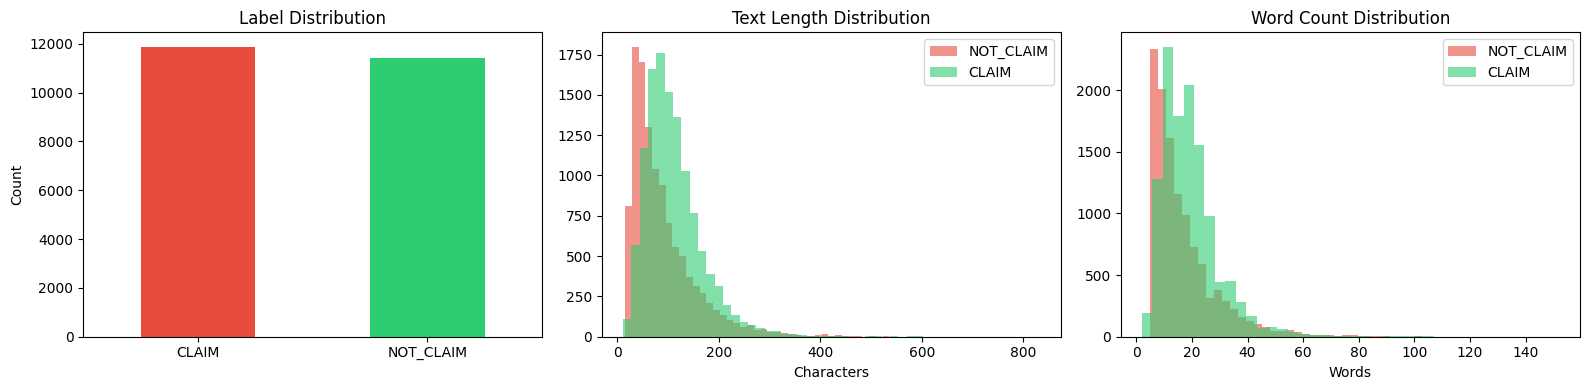


Text length stats by label:


,count,mean,min,max
label_name,,,,
CLAIM,11872.0,111.0,11.0,833.0
NOT_CLAIM,11404.0,89.0,15.0,683.0


In [5]:
# Text length distribution
df["text_len"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Label distribution
df["label_name"].value_counts().plot.bar(ax=axes[0], color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Label Distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Text length by label
for label, color in [(0, "#e74c3c"), (1, "#2ecc71")]:
    subset = df[df["label"] == label]["text_len"]
    axes[1].hist(subset, bins=50, alpha=0.6, label=LABEL_NAMES[label], color=color)
axes[1].set_title("Text Length Distribution")
axes[1].set_xlabel("Characters")
axes[1].legend()

# Word count by label
for label, color in [(0, "#e74c3c"), (1, "#2ecc71")]:
    subset = df[df["label"] == label]["word_count"]
    axes[2].hist(subset, bins=40, alpha=0.6, label=LABEL_NAMES[label], color=color)
axes[2].set_title("Word Count Distribution")
axes[2].set_xlabel("Words")
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary stats
print("\nText length stats by label:")
df.groupby("label_name")["text_len"].describe()[["count", "mean", "min", "max"]].round(0)

In [6]:
# Sample examples per class
for label in [1, 0]:
    name = LABEL_NAMES[label]
    print(f"\n=== {name} examples ===")
    for _, row in df[df["label"] == label].sample(10, random_state=42).iterrows():
        print(f"  [{label}] {row['text'][:120]}")


=== CLAIM examples ===
  [1] Now she's blaming the lie on the late, great Abraham Lincoln.
  [1] [The] ACLU and atheists in Denver are demanding the NFL stop [Tim Tebow] from praying on the sidelines.
  [1] We are amassing most of our military strength in a country where fewer than 100 members of al Qaeda remain.
  [1] Georgia is one of seven states to lose jobs in 2011 and has lost 8,200 jobs so far.
  [1] Says state lawmakers have voted to spend virtually all of the Rainy Day Fund four times since the funds creation.
  [1] The Wall Street Journal said 96 percent of small businesses are not affected at all by my plan.
  [1] Terrorists can now come into America and go to a gun show and, without even a background check, buy an assault weapon to
  [1] We admit about 100,000 permanent immigrants from the Middle East every year.
  [1] One of the reasons is we almost had it done, and the speaker -- a very, able, decent fellow, I might add -- but he twist
  [1] Says she introduced a ban on 

In [7]:
# Dataset already split — use as-is
def prepare_split(split_ds):
    split_df = split_ds.to_pandas()
    split_df["text"] = split_df["text"].astype(str).str.strip()
    split_df = split_df[split_df["text"].str.len() >= 10].reset_index(drop=True)
    split_df["label"] = split_df["checkworthiness"].astype(int)
    return split_df


splits = {
    "train": prepare_split(ds["train"]),
    "validation": prepare_split(ds["valid"]),
    "test": prepare_split(ds["test"]),
}

print(f"{'Split':>12} {'Total':>6} {'CLAIM':>6} {'NOT':>6} {'Ratio':>6}")
print("-" * 40)
for name, split_df in splits.items():
    c = split_df["label"].sum()
    print(f"{name:>12} {len(split_df):>6} {c:>6} {len(split_df) - c:>6} {100 * c / len(split_df):>5.0f}%")

       Split  Total  CLAIM    NOT  Ratio
----------------------------------------
       train  23276  11872  11404    51%
  validation   5819   2924   2895    50%
        test   7274   3691   3583    51%


## 4. Tokenize + PyTorch Dataset

In [8]:
MODEL_NAME = CONFIG["model_base"]
MAX_LENGTH = CONFIG["max_length"]

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class ClaimDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length):
        self.encodings = tokenizer(
            dataframe["text"].tolist(),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(dataframe["label"].values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx],
        }


train_ds = ClaimDataset(splits["train"], tokenizer, MAX_LENGTH)
val_ds = ClaimDataset(splits["validation"], tokenizer, MAX_LENGTH)
test_ds = ClaimDataset(splits["test"], tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["eval_batch_size"])
test_loader = DataLoader(test_ds, batch_size=CONFIG["eval_batch_size"])

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
print(f"Batches/epoch: {len(train_loader)}")

Train: 23276, Val: 5819, Test: 7274
Batches/epoch: 1455


## 5. Model

In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "NOT_CLAIM", 1: "CLAIM"},
    label2id={"NOT_CLAIM": 0, "CLAIM": 1},
    ignore_mismatched_sizes=True,
    dtype=torch.float32,
)
model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:>12,}")
print(f"Trainable params: {trainable:>12,}")

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias          

Total params:      184,423,682
Trainable params:  184,423,682


## 6. Training Loop + MLflow

In [10]:
EPOCHS = CONFIG["epochs"]
LR = CONFIG["learning_rate"]
PATIENCE = CONFIG["early_stopping_patience"]
OUTPUT_DIR = Path(CONFIG["output_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=CONFIG["weight_decay"])
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * CONFIG["warmup_ratio"])
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)


def evaluate(loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            out = model(input_ids=ids, attention_mask=mask, labels=labels)
            total_loss += out.loss.item() * len(labels)
            all_preds.extend(out.logits.argmax(dim=-1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    n = len(loader.dataset)
    return (
        {
            "loss": total_loss / n,
            "accuracy": accuracy_score(all_labels, all_preds),
            "f1": f1_score(all_labels, all_preds, pos_label=1),
            "precision": precision_score(all_labels, all_preds, pos_label=1, zero_division=0),
            "recall": recall_score(all_labels, all_preds, pos_label=1, zero_division=0),
        },
        all_preds,
        all_labels,
    )


print(f"Epochs: {EPOCHS}, lr: {LR}, warmup: {warmup_steps}/{total_steps}")
print(f"Early stopping: patience={PATIENCE} on val F1")

Epochs: 5, lr: 2e-05, warmup: 727/7275
Early stopping: patience=2 on val F1


In [11]:
# MLflow tracks all experiments locally in mlruns/
mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment(CONFIG["mlflow_experiment"])

from tqdm.auto import tqdm

history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_acc": []}

# Save initial checkpoint so OUTPUT_DIR is always valid
model.save_pretrained(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))

with mlflow.start_run(run_name="deberta-v3-base-claim-detector") as run:
    mlflow.log_params(CONFIG)
    mlflow.log_params(
        {"train_size": len(train_ds), "val_size": len(val_ds), "test_size": len(test_ds), "device": str(DEVICE)}
    )

    best_f1 = -1.0
    patience_counter = 0
    t_start = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=True)
        for step, batch in enumerate(pbar, 1):
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            optimizer.zero_grad()
            out = model(input_ids=ids, attention_mask=mask, labels=labels)
            loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            epoch_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")

            g_step = (epoch - 1) * len(train_loader) + step
            if step % 20 == 0:
                mlflow.log_metric("train/loss_step", loss.item(), step=g_step)

        avg_loss = epoch_loss / len(train_loader)
        val_m, _, _ = evaluate(val_loader)

        history["train_loss"].append(avg_loss)
        history["val_loss"].append(val_m["loss"])
        history["val_f1"].append(val_m["f1"])
        history["val_acc"].append(val_m["accuracy"])

        mlflow.log_metrics(
            {
                "train/loss_epoch": avg_loss,
                "val/loss": val_m["loss"],
                "val/f1": val_m["f1"],
                "val/accuracy": val_m["accuracy"],
                "val/precision": val_m["precision"],
                "val/recall": val_m["recall"],
            },
            step=epoch,
        )

        tag = ""
        if val_m["f1"] > best_f1:
            best_f1 = val_m["f1"]
            patience_counter = 0
            model.save_pretrained(str(OUTPUT_DIR))
            tokenizer.save_pretrained(str(OUTPUT_DIR))
            tag = " ** saved"
        else:
            patience_counter += 1
            tag = f" (patience {patience_counter}/{PATIENCE})"

        print(f"  val_f1={val_m['f1']:.4f} val_acc={val_m['accuracy']:.4f} train_loss={avg_loss:.4f}{tag}")

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    total_time = time.time() - t_start
    mlflow.log_metrics({"train/total_seconds": total_time, "val/best_f1": best_f1})
    print(f"\nDone! {total_time:.0f}s, best val F1={best_f1:.4f}")

/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/10 15:49:44 INFO mlflow.tracking.fluent: Experiment with name 'verifyn-claim-detector' does not exist. Creating a new experiment.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/5:   0%|          | 0/1455 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  val_f1=0.9188 val_acc=0.9215 train_loss=0.2971 ** saved


...

Epoch 4/5:   0%|          | 0/1455 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  val_f1=0.9306 val_acc=0.9309 train_loss=0.0523 ** saved


Epoch 5/5:   0%|          | 0/1455 [00:00<?, ?it/s]

  val_f1=0.9274 val_acc=0.9270 train_loss=0.0237 (patience 1/2)

Done! 6418s, best val F1=0.9306


## 7. Training Curves

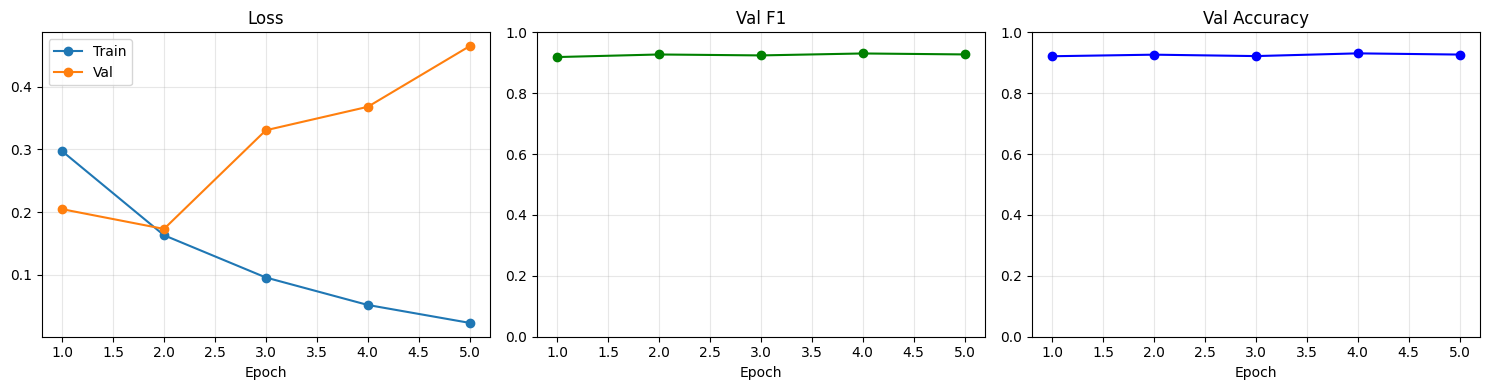

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(history["train_loss"]) + 1)

axes[0].plot(ep, history["train_loss"], "o-", label="Train")
axes[0].plot(ep, history["val_loss"], "o-", label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history["val_f1"], "o-", color="green")
axes[1].set_title("Val F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

axes[2].plot(ep, history["val_acc"], "o-", color="blue")
axes[2].set_title("Val Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "training_curves.png"), dpi=150)
plt.show()

## 8. Test Set Evaluation

In [13]:
# Load best checkpoint
model = AutoModelForSequenceClassification.from_pretrained(str(OUTPUT_DIR))
model.to(DEVICE)
model.eval()

test_m, test_preds, test_labels = evaluate(test_loader)

print("Test Results:")
for k, v in test_m.items():
    print(f"  {k:<12} {v:.4f}")

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_metrics({f"test/{k}": v for k, v in test_m.items()})

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Test Results:
  loss         0.4194
  accuracy     0.9210
  f1           0.9206
  precision    0.9391
  recall       0.9027


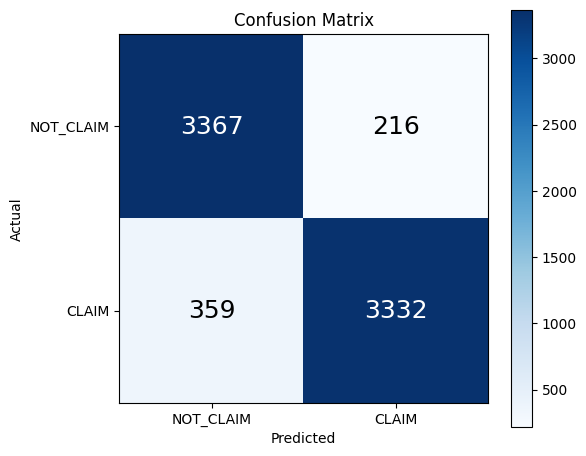


Classification Report:
              precision    recall  f1-score   support

   NOT_CLAIM       0.90      0.94      0.92      3583
       CLAIM       0.94      0.90      0.92      3691

    accuracy                           0.92      7274
   macro avg       0.92      0.92      0.92      7274
weighted avg       0.92      0.92      0.92      7274



In [14]:
# Confusion Matrix
LABELS = ["NOT_CLAIM", "CLAIM"]
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(LABELS)
ax.set_yticklabels(LABELS)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=18,
        )
plt.colorbar(im)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "confusion_matrix.png"), dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=LABELS))

# Save artifacts
cm_data = {
    "labels": LABELS,
    "matrix": cm.tolist(),
    "report": classification_report(test_labels, test_preds, target_names=LABELS, output_dict=True),
}
(OUTPUT_DIR / "confusion_matrix.json").write_text(json.dumps(cm_data, indent=2))

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(OUTPUT_DIR / "confusion_matrix.png"))
    mlflow.log_artifact(str(OUTPUT_DIR / "confusion_matrix.json"))
    mlflow.log_artifact(str(OUTPUT_DIR / "training_curves.png"))

## 9. Test Inference

In [15]:
def predict_claims(texts, model, tokenizer, device, threshold=0.5):
    if isinstance(texts, str):
        texts = [texts]
    inputs = tokenizer(texts, truncation=True, padding=True, max_length=256, return_tensors="pt").to(device)
    with torch.no_grad():
        probs = torch.softmax(model(**inputs).logits, dim=-1)
    results = []
    for i, text in enumerate(texts):
        score = probs[i][1].item()
        results.append(
            {"text": text, "label": "CLAIM" if score >= threshold else "NOT_CLAIM", "score": round(score, 4)}
        )
    return results


test_texts = [
    "NASA confirmed that water exists on Mars",
    "The unemployment rate dropped to 3.4% in January 2023",
    "Russia invaded Ukraine on February 24, 2022",
    "COVID-19 vaccines contain microchips",
    "I think this movie was really great",
    "How do I reset my password?",
    "Good morning everyone!",
    "asdfghjkl random words here",
    "In my humble opinion, pizza is the best food",
]

results = predict_claims(test_texts, model, tokenizer, DEVICE)

print(f"{'Text':<55} {'Label':<12} {'Score'}")
print("-" * 75)
for r in results:
    icon = "+" if r["label"] == "CLAIM" else "-"
    print(f"{icon} {r['text'][:52]:<55} {r['label']:<12} {r['score']:.3f}")

Text                                                    Label        Score
---------------------------------------------------------------------------
+ NASA confirmed that water exists on Mars                CLAIM        1.000
+ The unemployment rate dropped to 3.4% in January 202    CLAIM        1.000
+ Russia invaded Ukraine on February 24, 2022             CLAIM        1.000
+ COVID-19 vaccines contain microchips                    CLAIM        1.000
- I think this movie was really great                     NOT_CLAIM    0.000
- How do I reset my password?                             NOT_CLAIM    0.001
- Good morning everyone!                                  NOT_CLAIM    0.000
- asdfghjkl random words here                             NOT_CLAIM    0.001
- In my humble opinion, pizza is the best food            NOT_CLAIM    0.000


## 11. Save Model

In [16]:
for f in sorted(OUTPUT_DIR.iterdir()):
    size = f.stat().st_size / 1024 / 1024
    print(f"  {f.name:<40} {size:.1f} MB")

  config.json                              0.0 MB
  confusion_matrix.json                    0.0 MB
  confusion_matrix.png                     0.0 MB
  model.safetensors                        703.5 MB
  tokenizer.json                           8.0 MB
  tokenizer_config.json                    0.0 MB
  training_curves.png                      0.1 MB


In [17]:
import shutil

shutil.make_archive("claim_detector", "zip", str(OUTPUT_DIR))

'/teamspace/studios/this_studio/claim_detector.zip'